In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error
from sklearn.linear_model import LinearRegression,LassoCV,ridge_regression,ElasticNet,LogisticRegressionCV


In [2]:
df=pd.read_csv("AmesHousing.csv")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,2001,2001,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,616.0,Unf,0.0,722.0,1338.0,GasA,Ex,Y,SBrkr,1338,0,0,1338,1.0,0.0,2,0,2,1,Gd,6,Typ,0,NaN,Attchd,2001.0,Fin,2.0,582.0,TA,TA,Y,0,0,170,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1995,1996,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,1180.0,Unf,0.0,415.0,1595.0,GasA,Ex,Y,SBrkr,1616,0,0,1616,1.

In [5]:
df.shape

(2930, 82)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [7]:
df["Garage Cars"].value_counts()

,count
Garage Cars,
2.0,1603
1.0,778
3.0,374
0.0,157
4.0,16
5.0,1


In [8]:
df["Pool Area"].value_counts()

,count
Pool Area,
0,2917
144,1
480,1
576,1
555,1
368,1
444,1
228,1
561,1


In [9]:
df["Lot Frontage"].value_counts()

,count
Lot Frontage,
60.0,276
80.0,137
70.0,133
50.0,117
75.0,105
...,...
168.0,1
111.0,1
131.0,1


In [10]:
df["Misc Feature"].unique()

array([nan, 'Gar2', 'Shed', 'Othr', 'Elev', 'TenC'], dtype=object)

In [11]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [12]:
df.isnull().sum().to_frame(name="Missing Values")


,Missing Values
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,490
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


Handling Missing Values

In [13]:
df["Lot Frontage"]=df["Lot Frontage"].fillna(df["Lot Frontage"].median())
df["Alley"]=df["Alley"].fillna("No Alley")
df["Mas Vnr Area"]=df["Mas Vnr Area"].fillna(0)
df["Mas Vnr Type"]=df["Mas Vnr Type"].fillna("No Vnr")
df["Misc Feature"]=df["Misc Feature"].fillna("No feature")
df["Fence"]=df["Fence"].fillna("No fence")

In [14]:
df["Pool QC"]=df["Pool QC"].fillna("No pool")
df["Fireplace Qu"]=df["Fireplace Qu"].fillna("No Fireplace")

In [15]:
df["Electrical"]=df["Electrical"].fillna("No Fuse")

In [16]:
df["Garage Type"]=df["Garage Type"].fillna("no garage")
df["Garage Finish"]=df["Garage Finish"].fillna("no garage")
df["Garage Qual"]=df["Garage Qual"].fillna("no garage")
df["Garage Cond"]=df["Garage Cond"].fillna("no garage")
df["Garage Yr Blt"]=df["Garage Yr Blt"].fillna(0)
df["Garage Area"]=df["Garage Area"].fillna(df["Garage Area"].mean())
df["Garage Cars"]=df["Garage Cars"].fillna(0)

In [17]:
ncols=['BsmtFin SF 1','BsmtFin SF 2','Bsmt Unf SF','Bsmt Full Bath','Bsmt Half Bath','Total Bsmt SF']
for col in ncols:
  df[col]=df[col].fillna(0)
ccols=['Bsmt Qual',"Bsmt Cond", "Bsmt Exposure",'BsmtFin Type 1','BsmtFin Type 2']
for col in ccols:
  df[col]=df[col].fillna("No Basement")

In [18]:
cat_cols=['Land Contour', 'BsmtFin Type 1', 'Heating QC', 'Garage Cond', 'Paved Drive', 'Alley', 'MS Zoning', 'Garage Qual', 'Roof Matl', 'Land Slope', 'Exter Cond', 'Garage Type', 'Central Air', 'Bldg Type', 'Fence', 'Neighborhood', 'Fireplace Qu', 'Bsmt Exposure', 'Sale Condition', 'Kitchen Qual', 'Foundation', 'Lot Shape', 'Lot Config', 'Pool QC', 'Roof Style', 'Electrical', 'Condition 2', 'Bsmt Qual', 'Sale Type', 'Misc Feature', 'BsmtFin Type 2', 'Bsmt Cond', 'Garage Finish', 'Condition 1', 'Mas Vnr Type', 'Street', 'Exterior 1st', 'Exter Qual', 'Utilities', 'Heating', 'Functional', 'Exterior 2nd', 'House Style']

In [19]:
num_cols=['Yr Sold', 'Kitchen AbvGr', 'Lot Area', '3Ssn Porch', 'MS SubClass', '1st Flr SF', 'Gr Liv Area', 'Fireplaces', 'Bsmt Unf SF', 'Total Bsmt SF', 'Overall Qual', 'Pool Area', 'Bsmt Half Bath', 'Mas Vnr Area', 'SalePrice', 'Year Built', 'Lot Frontage', 'Full Bath', 'PID', 'Garage Area', 'BsmtFin SF 2', 'BsmtFin SF 1', 'Bedroom AbvGr', 'Garage Cars', 'TotRms AbvGrd', 'Bsmt Full Bath', 'Screen Porch', 'Open Porch SF', 'Year Remod/Add', 'Overall Cond', 'Garage Yr Blt', '2nd Flr SF', 'Half Bath', 'Order', 'Wood Deck SF', 'Misc Val', 'Enclosed Porch', 'Mo Sold', 'Low Qual Fin SF']

EDA

(array([ 11., 135., 451., 882., 565., 343., 210., 119.,  88.,  46.,  35.,
         16.,  11.,   3.,   6.,   3.,   4.,   0.,   0.,   2.]),
 array([ 12789.  ,  49899.55,  87010.1 , 124120.65, 161231.2 , 198341.75,
        235452.3 , 272562.85, 309673.4 , 346783.95, 383894.5 , 421005.05,
        458115.6 , 495226.15, 532336.7 , 569447.25, 606557.8 , 643668.35,
        680778.9 , 717889.45, 755000.  ]),
 <BarContainer object of 20 artists>)

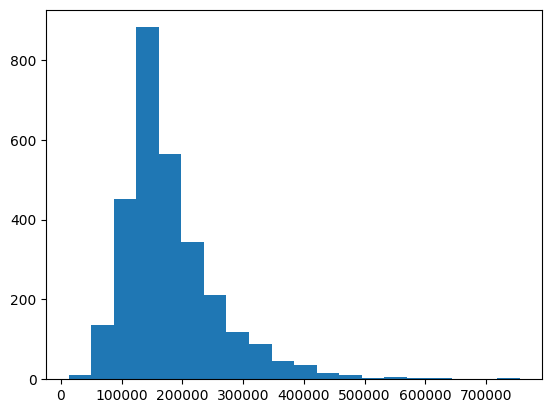

In [20]:
plt.hist(
    df['SalePrice'],
    bins=20
)

<Axes: xlabel='Bldg Type', ylabel='SalePrice'>

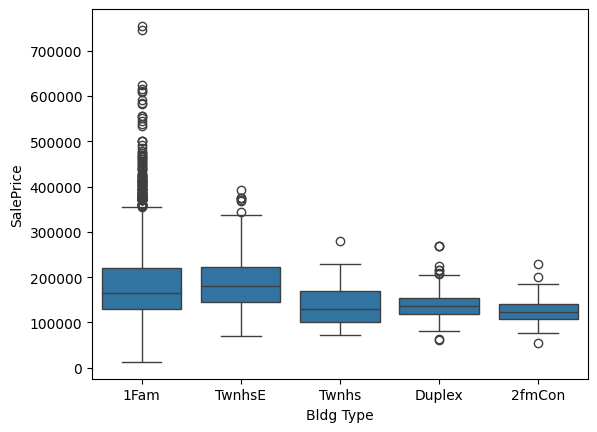

In [21]:
sns.boxplot(
    data=df,
    x='Bldg Type',
    y='SalePrice'
)

<Axes: xlabel='Garage Type', ylabel='SalePrice'>

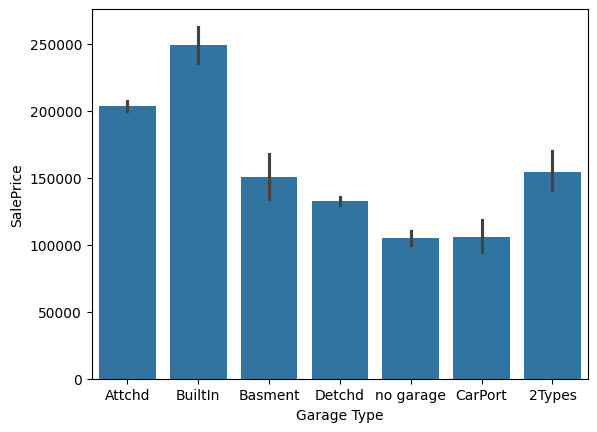

In [22]:
sns.barplot(
    data=df,
    x='Garage Type',
    y='SalePrice'
)

<Axes: xlabel='Central Air', ylabel='SalePrice'>

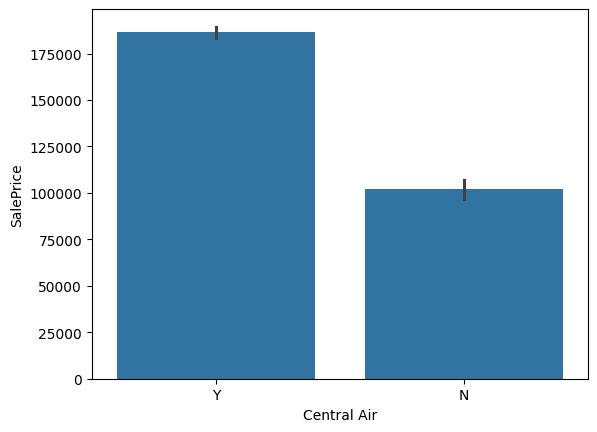

In [23]:
sns.barplot(
    data=df,
    x='Central Air',
    y='SalePrice'
)
#coclusion-> houses with central air has more sale price.

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

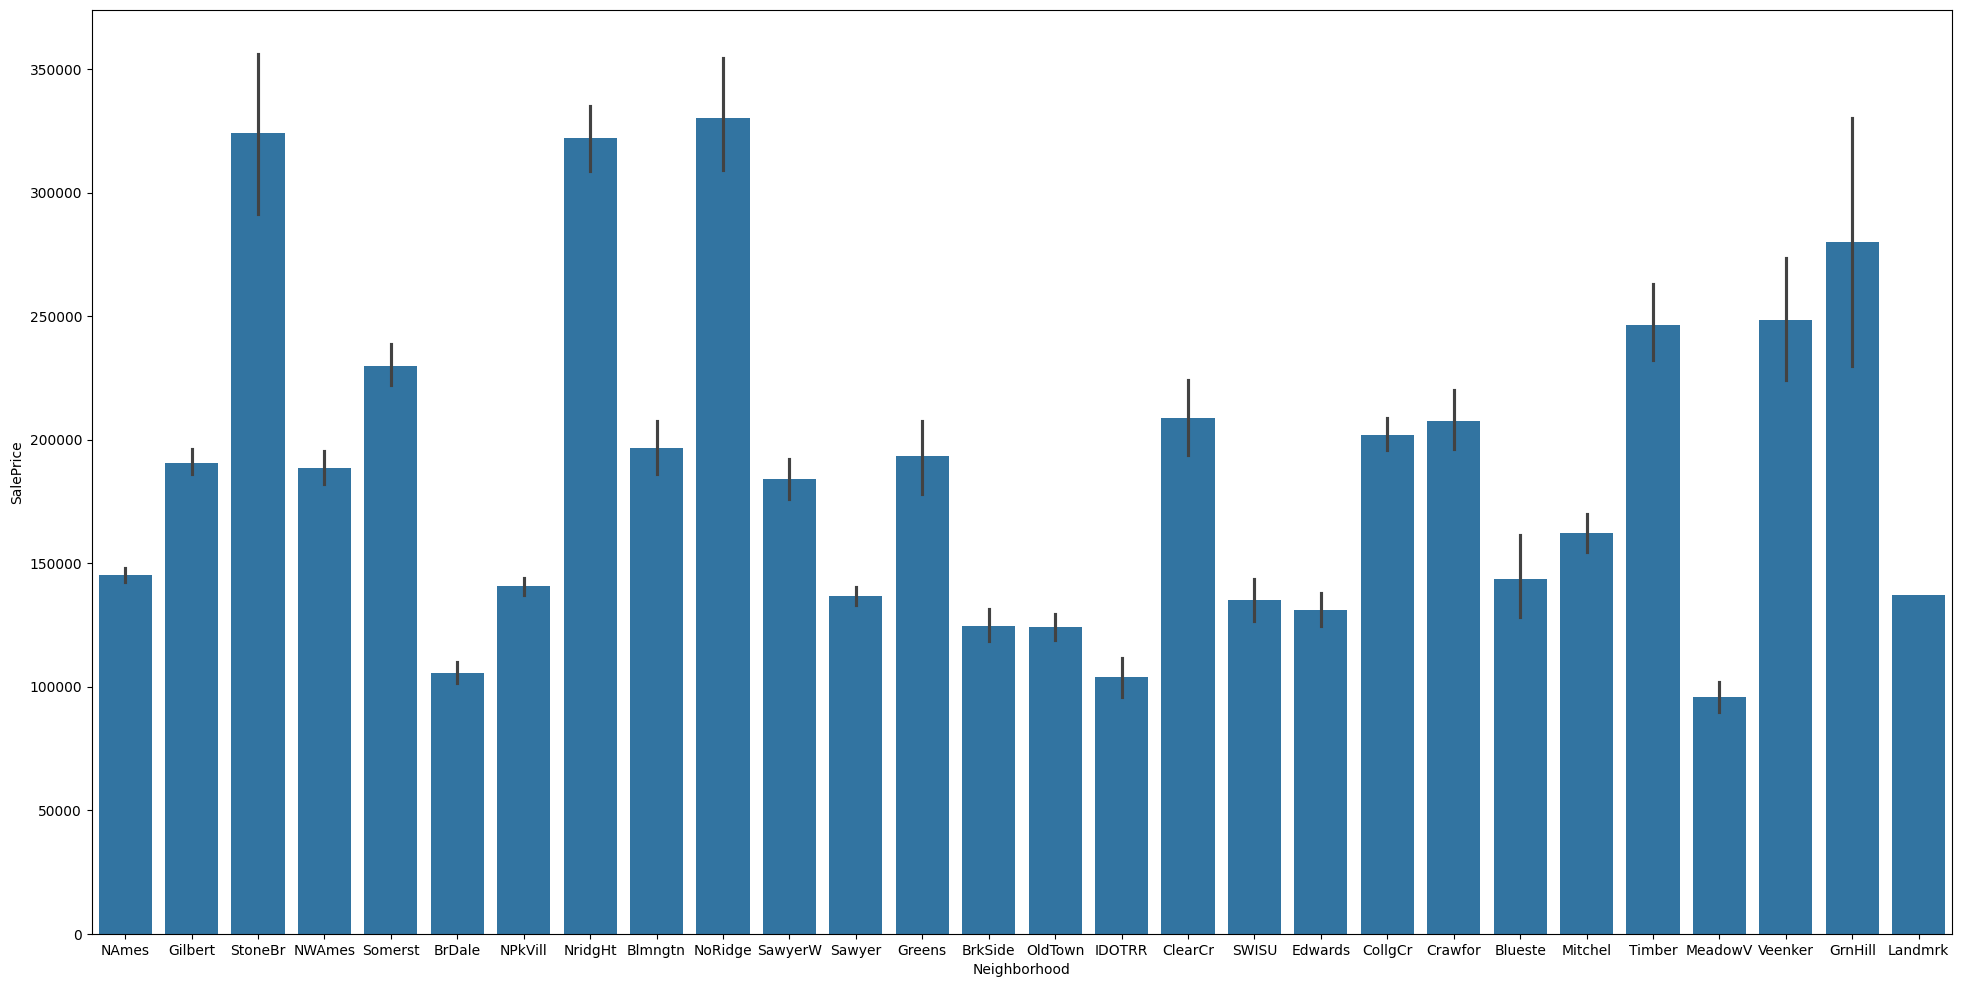

In [24]:
plt.figure(figsize=(24,12))
sns.barplot(
    data=df,
    x='Neighborhood',
    y='SalePrice'
)

<Axes: >

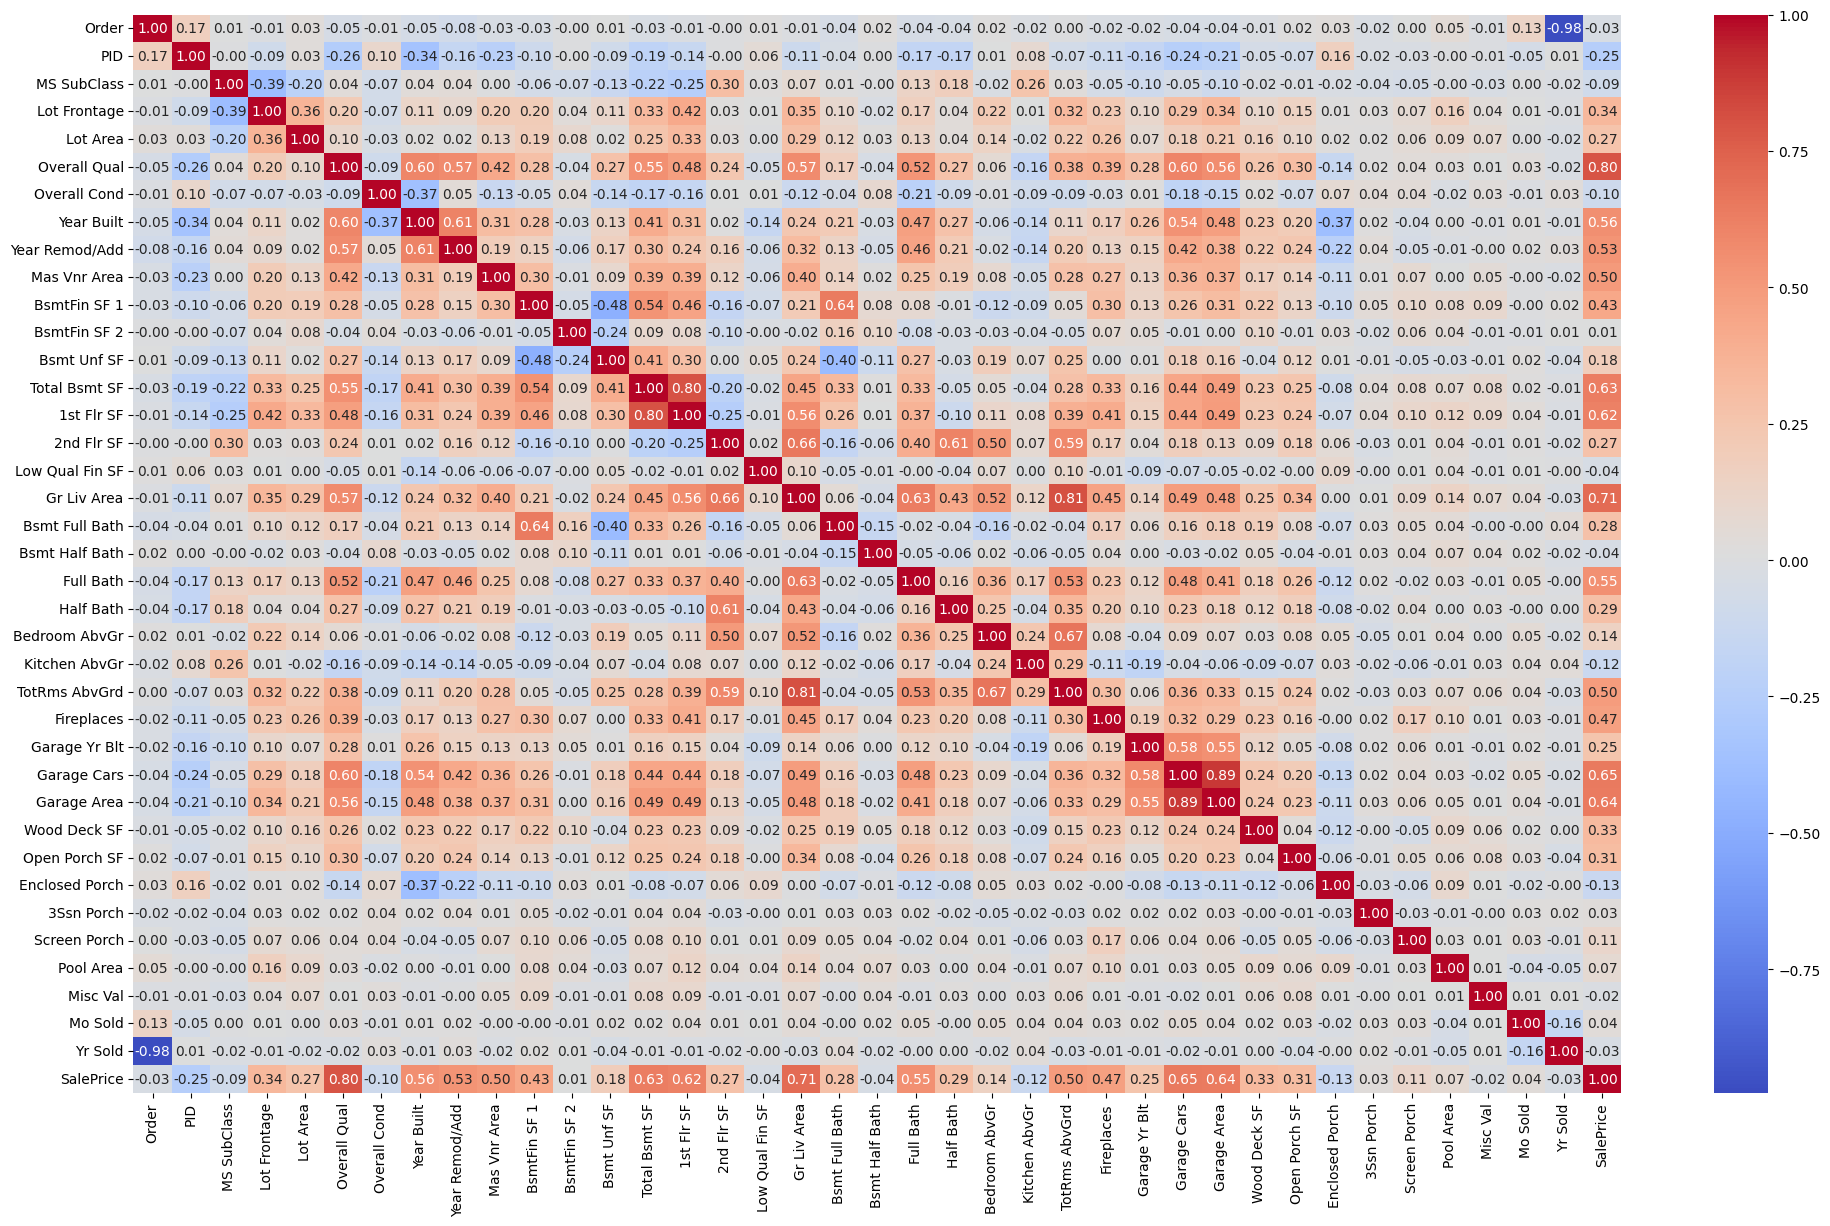

In [25]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(24,14))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt='.2f')
#the features which have positive influence on sales prices are- overall qual Gr Liv Area,Garage Yr Blt, Garage Cars, Gr Liv Area is highly influenced by TotRms AbvGr

##Feature Engineering

In [26]:
df["NYr Sold"]=df["Yr Sold"]-df["Year Built"]
df["Bathroms"]=df["Bsmt Full Bath"]+0.5*df["Bsmt Half Bath"]+df["Full Bath"]+0.5*df["Half Bath"]
df["Porch"]=df["Enclosed Porch"]+df["Open Porch SF"]+df["3Ssn Porch"]+df["Screen Porch"]
df["Yr Remodal"]=df["Yr Sold"] - df["Year Remod/Add"]

Encoding Categorical Variables

In [27]:
cat_cols=['Land Contour', 'BsmtFin Type 1', 'Heating QC', 'Garage Cond', 'Paved Drive', 'Alley', 'MS Zoning', 'Garage Qual', 'Roof Matl', 'Land Slope', 'Exter Cond', 'Garage Type', 'Central Air', 'Bldg Type', 'Fence', 'Neighborhood', 'Fireplace Qu', 'Bsmt Exposure', 'Sale Condition', 'Kitchen Qual', 'Foundation', 'Lot Shape', 'Lot Config', 'Pool QC', 'Roof Style', 'Electrical', 'Condition 2', 'Bsmt Qual', 'Sale Type', 'Misc Feature', 'BsmtFin Type 2', 'Bsmt Cond', 'Garage Finish', 'Condition 1', 'Mas Vnr Type', 'Street', 'Exterior 1st', 'Exter Qual', 'Utilities', 'Heating', 'Functional', 'Exterior 2nd', 'House Style']

In [28]:
for cols in cat_cols:
  print(cols,"->",df[cols].unique())


Land Contour -> ['Lvl' 'HLS' 'Bnk' 'Low']
BsmtFin Type 1 -> ['BLQ' 'Rec' 'ALQ' 'GLQ' 'Unf' 'LwQ' 'No Basement']
Heating QC -> ['Fa' 'TA' 'Ex' 'Gd' 'Po']
Garage Cond -> ['TA' 'no garage' 'Fa' 'Gd' 'Ex' 'Po']
Paved Drive -> ['P' 'Y' 'N']
Alley -> ['No Alley' 'Pave' 'Grvl']
MS Zoning -> ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']
Garage Qual -> ['TA' 'no garage' 'Fa' 'Gd' 'Ex' 'Po']
Roof Matl -> ['CompShg' 'WdShake' 'Tar&Grv' 'WdShngl' 'Membran' 'ClyTile' 'Roll'
 'Metal']
Land Slope -> ['Gtl' 'Mod' 'Sev']
Exter Cond -> ['TA' 'Gd' 'Fa' 'Po' 'Ex']
Garage Type -> ['Attchd' 'BuiltIn' 'Basment' 'Detchd' 'no garage' 'CarPort' '2Types']
Central Air -> ['Y' 'N']
Bldg Type -> ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']
Fence -> ['No fence' 'MnPrv' 'GdPrv' 'GdWo' 'MnWw']
Neighborhood -> ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'B

In [29]:
ordinal_cols=["Heating QC" , "Garage Cond" , "Garage Qual" , "Exter Cond" , "Fireplace Qu" , "Kitchen Qual" , "Pool QC" , "Bsmt Qual" , "Bsmt Cond" , "Exter Qual"]
nominal_cols=list(set(cat_cols)-set(ordinal_cols))

In [30]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
ohe=OneHotEncoder(drop="first",sparse_output=False)
enc_nominal_cols=ohe.fit_transform(df[nominal_cols])
df_enc=pd.DataFrame(enc_nominal_cols,columns=ohe.get_feature_names_out(nominal_cols),index=df.index)

In [31]:
quality_map = {
    "No Basement": 0,
    "no garage": 0,
    "No Fireplace": 0,
    "No pool": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}
for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

In [32]:
# Final dataframe
df_final = pd.concat(
    [df.drop(columns=nominal_cols), df_enc],
    axis=1
)

In [33]:
print(df_final.shape)
print(df_final.isnull().sum().sum())
print(df_final.select_dtypes(include="object").columns)

(2930, 249)
0
Index([], dtype='object')


In [34]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Columns: 249 entries, Order to Mas Vnr Type_Stone
dtypes: float64(208), int64(41)
memory usage: 5.6 MB


##Building Model

In [35]:
x=df_final.drop(columns=["SalePrice","Order","PID"],axis=1)
y=df_final["SalePrice"]

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:

def evaluate(model, x_train, x_test, y_train, y_test):

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    print("="*50)
    print(type(model).__name__)

    print("\nTrain Performance")
    print("R2 Score :", r2_score(y_train, y_pred_train))
    print("MAE :", mean_absolute_error(y_train, y_pred_train))
    print("MSE :", mean_squared_error(y_train, y_pred_train))
    print("RMSE :", root_mean_squared_error(y_train, y_pred_train))

    print("\nTest Performance")
    print("R2 Score :", r2_score(y_test, y_pred_test))
    print("MAE :", mean_absolute_error(y_test, y_pred_test))
    print("MSE :", mean_squared_error(y_test, y_pred_test))
    print("RMSE :", root_mean_squared_error(y_test, y_pred_test))

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [39]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="adaptive",
    eta0=0.001,
    max_iter=5000,
    tol=1e-3,
    random_state=42
)

sgd.fit(x_train_scaled, y_train)

evaluate(
    sgd,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

SGDRegressor

Train Performance
R2 Score : -80.0061116789035
MAE : 427110.14527077065
MSE : 481641212042.9441
RMSE : 694003.7550640083

Test Performance
R2 Score : -51.07323472995081
MAE : 433428.6385324113
MSE : 417499655364.7912
RMSE : 646142.132479218


In [40]:
from sklearn.linear_model import RidgeCV

alphas = [0.001, 0.01, 0.1, 1, 10, 20, 50, 100]

ridge = RidgeCV(
    alphas=alphas,
    cv=5
)

ridge.fit(x_train_scaled, y_train)

print("Best Alpha :", ridge.alpha_)
evaluate(
    ridge,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

Best Alpha : 100.0
RidgeCV

Train Performance
R2 Score : 0.9115674199009992
MAE : 15004.004492441349
MSE : 525797056.2986542
RMSE : 22930.265072577207

Test Performance
R2 Score : 0.885318344597056
MAE : 17837.24776765465
MSE : 919465668.9889497
RMSE : 30322.69231102261


In [41]:
coef = pd.DataFrame({

    "Feature":x.columns,

    "Coefficient":ridge.coef_

})

coef = coef.sort_values(

    by="Coefficient",

    key=abs,

    ascending=False

)

coef.head(15)

,Feature,Coefficient
20,Gr Liv Area,12717.152537
182,Roof Matl_CompShg,12328.157722
3,Overall Qual,11309.975526
18,2nd Flr SF,9420.730202
188,Roof Matl_WdShngl,8801.187190
43,Misc Val,-8024.319691
186,Roof Matl_Tar&Grv,7954.913454
88,Neighborhood_NridgHt,7713.235275
17,1st Flr SF,6238.659625
127,Misc Feature_Gar2,5921.748096


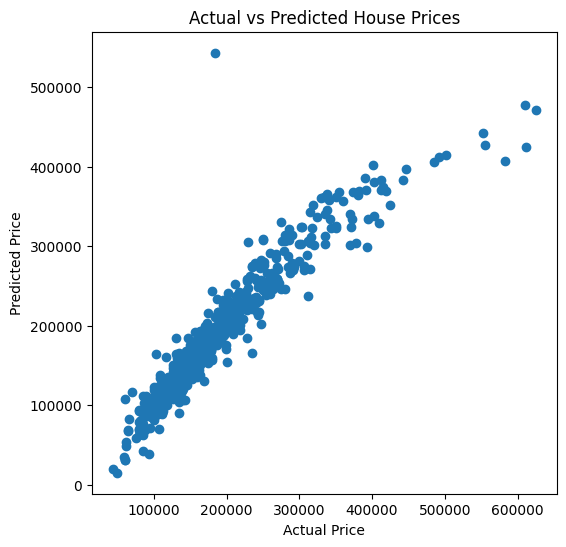

In [42]:
y_pred_test = ridge.predict(x_test_scaled)

plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred_test)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

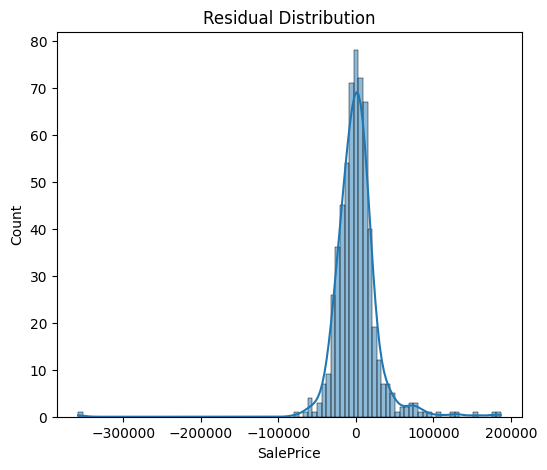

In [43]:
residuals = y_test-y_pred_test

plt.figure(figsize=(6,5))

sns.histplot(residuals,kde=True)

plt.title("Residual Distribution")

plt.show()

In [44]:
from sklearn.linear_model import LassoCV

alphas = [0.001, 0.01, 0.1, 1, 10, 20, 50, 100]

lasso = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=100000,
    random_state=42
)

lasso.fit(x_train_scaled, y_train)

print("Best Alpha :", lasso.alpha_)
evaluate(
    lasso,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

Best Alpha : 100.0
LassoCV

Train Performance
R2 Score : 0.9269173876452514
MAE : 14327.12325125348
MSE : 434530151.6672203
RMSE : 20845.386819803087

Test Performance
R2 Score : 0.8838061697317436
MAE : 17397.657171395032
MSE : 931589603.4515058
RMSE : 30521.952811894356


In [45]:
from sklearn.linear_model import ElasticNetCV

elastic = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1],
    cv=5,
    max_iter=100000,
    random_state=42
)

elastic.fit(x_train_scaled, y_train)

print("Best Alpha :", elastic.alpha_)
print("Best L1 Ratio :", elastic.l1_ratio_)
evaluate(
    elastic,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

Best Alpha : 1.0
Best L1 Ratio : 0.7
ElasticNetCV

Train Performance
R2 Score : 0.8955923685737696
MAE : 15455.850674675923
MSE : 620780544.8802811
RMSE : 24915.4679843723

Test Performance
R2 Score : 0.8771734573748579
MAE : 18128.015702166445
MSE : 984767692.684762
RMSE : 31381.008471442754


In [46]:
print("Best Alpha (Ridge):", ridge.alpha_)
print("Best Alpha (Lasso):", lasso.alpha_)
print("Best Alpha (ElasticNet):", elastic.alpha_)
print("Best L1 Ratio:", elastic.l1_ratio_)

Best Alpha (Ridge): 100.0
Best Alpha (Lasso): 100.0
Best Alpha (ElasticNet): 1.0
Best L1 Ratio: 0.7


In [47]:
results = []

models = [sgd, ridge, lasso, elastic]

for model in models:
  y_pred_test = model.predict(x_test_scaled)

  results.append({
      "Model": type(model).__name__,
      "R2 Score": r2_score(y_test, y_pred_test),
      "MAE": mean_absolute_error(y_test, y_pred_test),
      "MSE": mean_squared_error(y_test, y_pred_test),
      "RMSE": root_mean_squared_error(y_test, y_pred_test)
  })

results_df = pd.DataFrame(results)

results_df

,Model,R2 Score,MAE,MSE,RMSE
0,SGDRegressor,-51.073235,433428.638532,4.174997e+11,646142.132479
1,RidgeCV,0.885318,17837.247768,9.194657e+08,30322.692311
2,LassoCV,0.883806,17397.657171,9.315896e+08,30521.952812
3,ElasticNetCV,0.877173,18128.015702,9.847677e+08,31381.008471


## Model Comparison

• we used SGDRegressor as the baseline model.

• Ridge Regression helped us to reduced overfitting by applying L2 regularization.

• Lasso Regression performed feature selection by scaling or shrinking some coefficients to zero.

• ElasticNet combined both L1 and L2 penalties, balanced feature selection and coefficient shrinkage.

• Based on the evaluation metrics, Ridge Regression achieved the best balance between bias and variance on this dataset, thus it is the best model here.

## Why SGDRegressor instead of LinearRegression?

we used SGDRegressor as the baseline model because it optimizes model parameters using Stochastic Gradient Descent (SGD). Unlike LinearRegression, which computes the exact analytical solution, SGDRegressor updates parameters iteratively and it is more suitable for large datasets. It is more memory-efficient, also supports online learning, and scales well for high-dimensional data.

# Conclusion

Twe successfully processed Ames Housing dataset, did all the steps like   missing value handling, feature engineering, categorical encoding, feature scaling, and train-test splitting.

According to the instruction we used SGDRegressor as the baseline model because this utilizes Gradient Descent optimization technique and is suitable for large datasets.

We trained multiple models like Ridge, Lasso, and ElasticNet Regression using cross validation .

Among all models, Ridge Regression achieved the best testing performance according to the R² score while maintaining low prediction error.